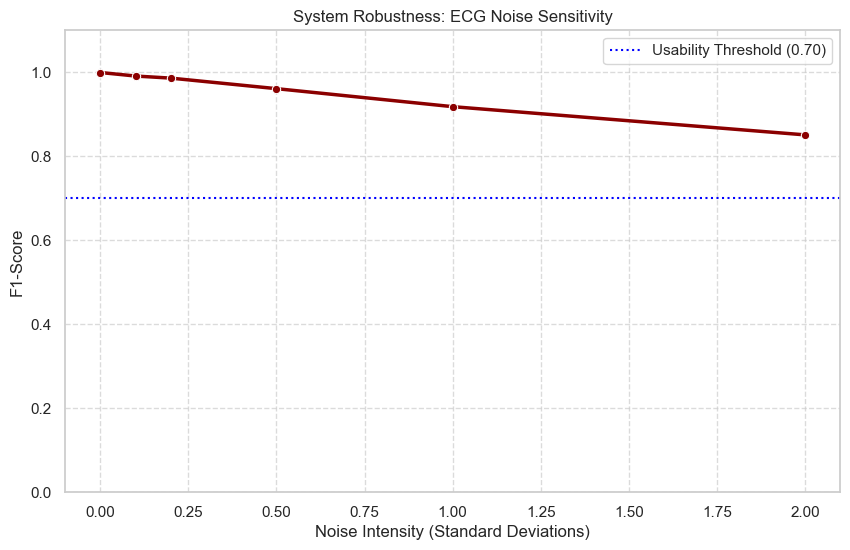

   Noise_Level  F1_Score
0          0.0  0.999212
1          0.1  0.990802
2          0.2  0.985834
3          0.5  0.960733
4          1.0  0.917887
5          2.0  0.850746


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

with open('final_fusion_model.pkl', 'rb') as f:
    model = pickle.load(f)

df = pd.read_csv('wesad_final_normalized_features.csv')

fusion_cols = model.feature_names_in_.tolist()

ecg_cols = [c for c in fusion_cols if 'HRV' in c or 'ECG_Rate' in c]

# Map labels to binary
y_true = df['label'].map({1: 0, 2: 1})

# Define noise levels (0 to 2 standard deviations)
noise_levels = [0, 0.1, 0.2, 0.5, 1.0, 2.0]
noise_results = []

# Add Incremental Noise to ECG Modality
for level in noise_levels:
    X_noisy = df[fusion_cols].copy()
    
    # Generate Gaussian Noise for the ECG features only
    # data is Z-scored, level=1.0 noise as strong as the signal
    noise = np.random.normal(0, level, size=(X_noisy.shape[0], len(ecg_cols)))
    X_noisy[ecg_cols] = X_noisy[ecg_cols] + noise
    
    preds = model.predict(X_noisy)
    f1 = f1_score(y_true, preds)
    noise_results.append({'Noise_Level': level, 'F1_Score': f1})

noise_df = pd.DataFrame(noise_results)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(data=noise_df, x='Noise_Level', y='F1_Score', marker='o', color='darkred', linewidth=2.5)

plt.title('System Robustness: ECG Noise Sensitivity')
plt.xlabel('Noise Intensity (Standard Deviations)')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.7)

plt.axhline(0.70, color='blue', linestyle=':', label='Usability Threshold (0.70)')
plt.legend()

plt.savefig('robustness_noise_sensitivity.png')
plt.show()

print(noise_df)